# Week 3 Day 5 Lab

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

### Problem 1
There is a famous book by Victor Hugo called "Les Miserables". Networkx features a network based on this book! The nodes correspond to characters. The edges correspond to whether each character appears together. You can call this graph by using `nx.les_miserables_graph()` like so:

In [16]:
g = nx.les_miserables_graph()

Again, an edge appears when two characters are in a situation together. More importantly, the "weight" of the edge corresponds to how <i>often</i> that occurs! For example, Myriel and Madame Magloire appear 10 times together:

In [17]:
g.edges[('Myriel', 'MmeMagloire')]

{'weight': 10}

In [18]:
g.edges[('Myriel', 'MmeMagloire')]['weight']

10

1. Plot the network using `networkx`
2. Plot the network with:
    - an appropriate size for the figure 
    - the names being legible
    - edge size corresponding to the weight
    - a title
3. By looking at the graph, who do you think the main character is?
4. Using `matplotlib`, plot the edge weights for this network (that is, plot how often characters appeared together). Make your plot as informative as possible.

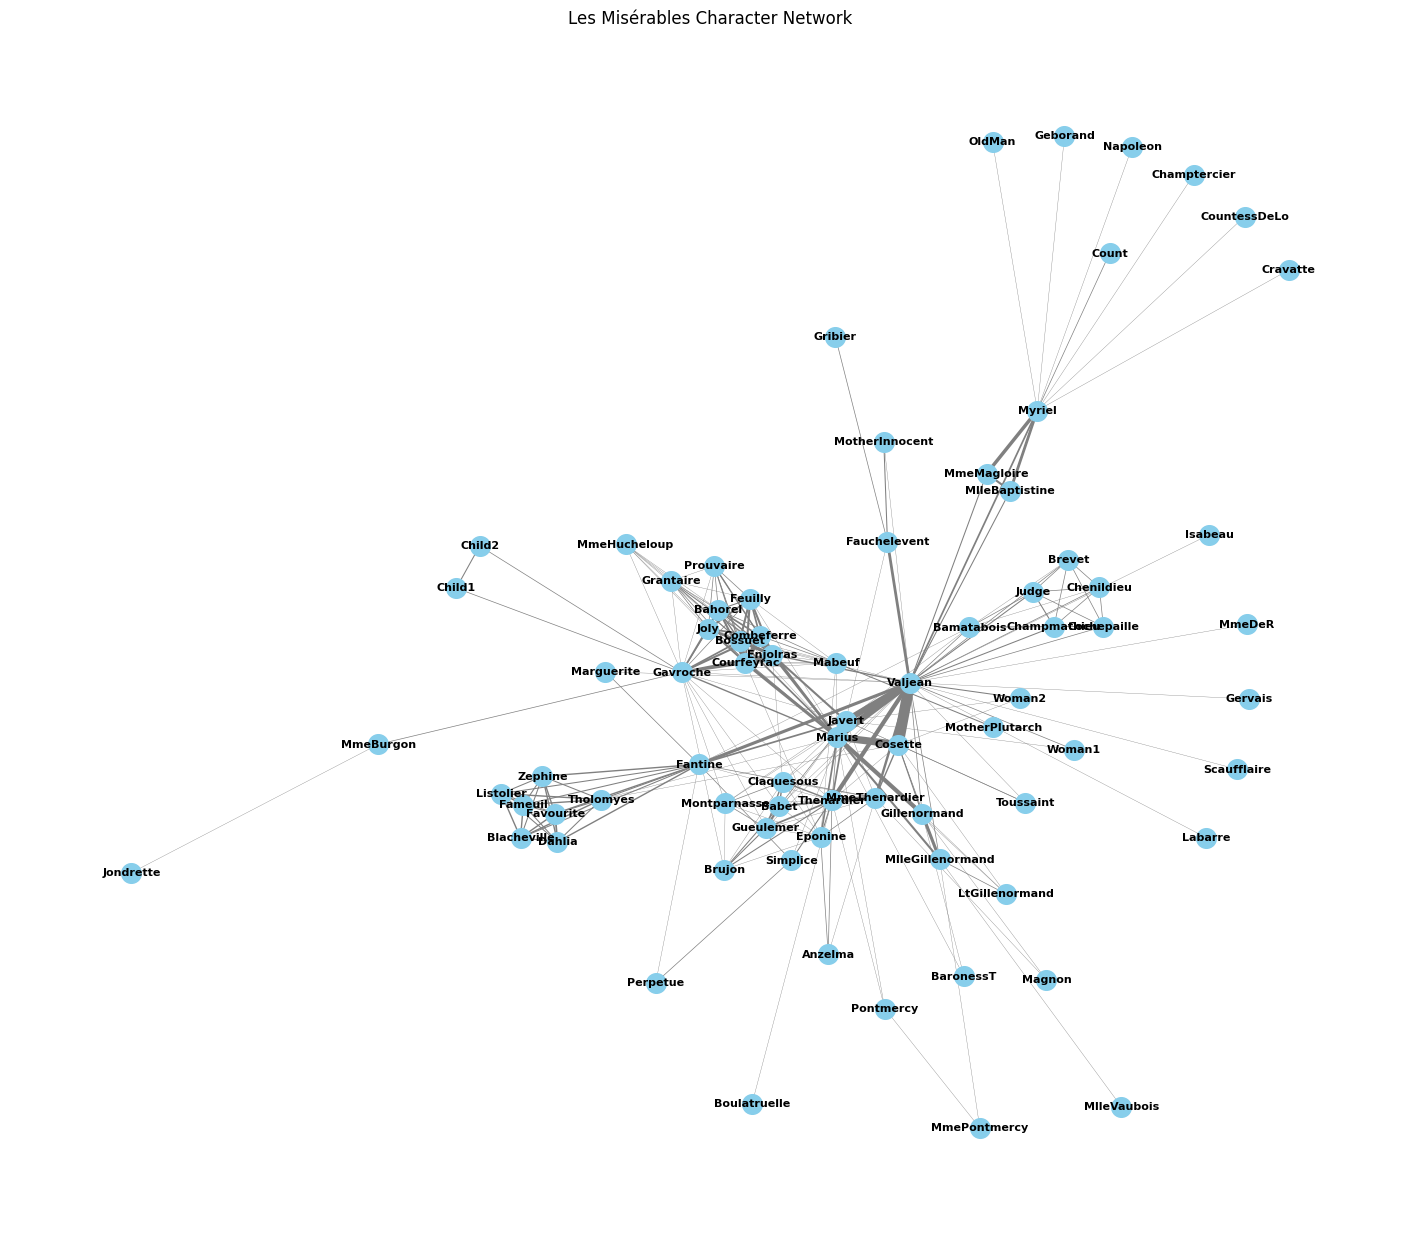

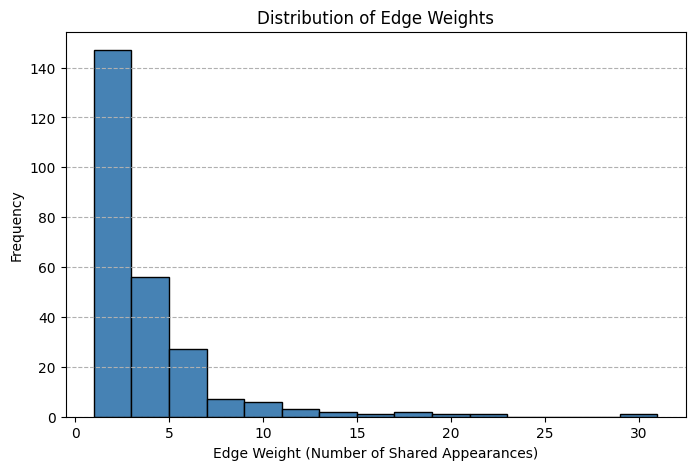

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.les_miserables_graph()
pos = nx.spring_layout(G, seed=20)

edge_widths = [G[u][v]["weight"] / 4 for u, v in G.edges()]

# Plot the network
plt.figure(figsize=(14, 12))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=200,
    node_color="skyblue",
    edge_color="gray",
    width=edge_widths,
    font_size=8,
    font_weight="bold"
)

plt.title("Les Misérables Character Network")
plt.axis("off")

# Distribution of Edge Weights
weights = [G[u][v]["weight"] for u, v in G.edges()]

plt.figure(figsize=(8, 5))

plt.hist(
    weights,
    bins=15,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Edge Weights")
plt.xlabel("Edge Weight (Number of Shared Appearances)")
plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--")

### Problem 2
There is another built in network that is relatively famous: the karate club graph. A karate club split in two after "Mr. Hi" and "John A" got in a disagreement. The nodes in this network are members of the club. The edges correspond to if they are friends outside of the club. You can access this graph by `nx.karate_club_graph()`

In [20]:
nx.karate_club_graph().nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

1. How many nodes are there?
2. How many edges?
3. Plot the network in a way that allows the labels and edges to be seen clearly.
4. Do you see any nodes that seem to be important to the network?
5. You can determine how many edges a given node is a part of by using `nx.degree()`. Plot the degrees of the nodes using whatever `matplotlib` function you like. Make this plot as informative as possible.
6. Node 0 and node 33 are the two administrators, Mr. Hi and John A, that caused the split. How do their degrees compare to the rest of the network?

Number of nodes: 34
Number of edges: 78
Degree of node 0: 16
Degree of node 33: 17


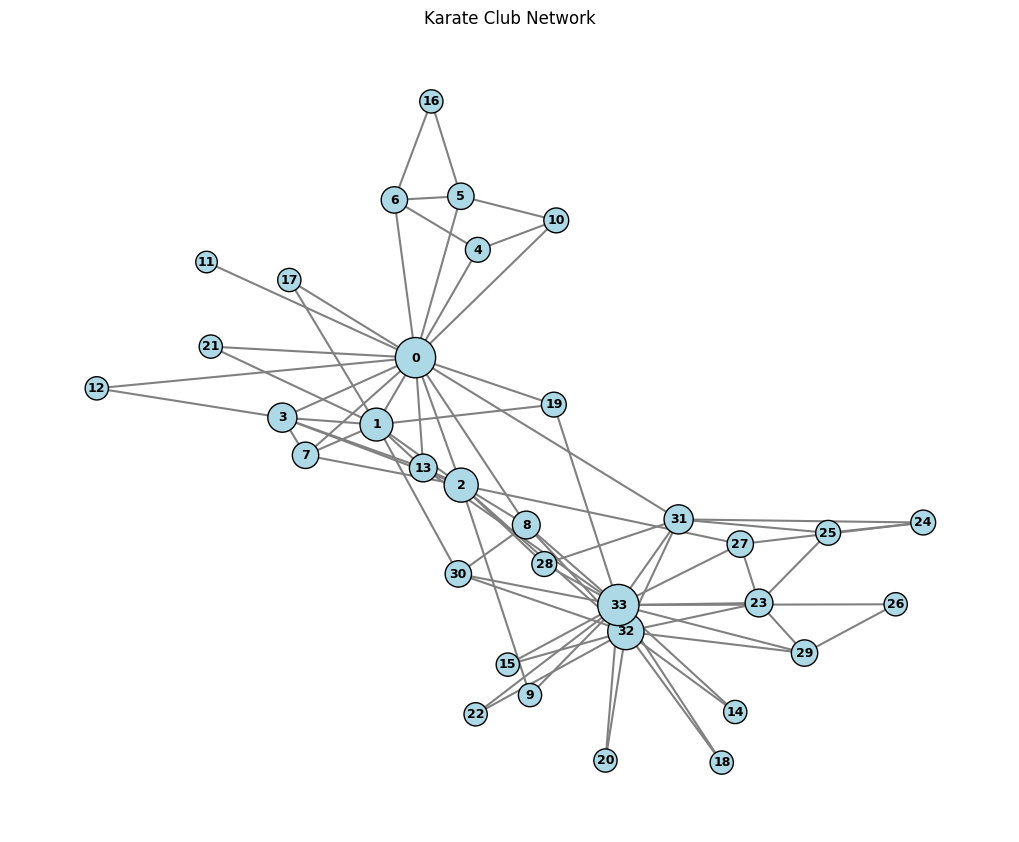

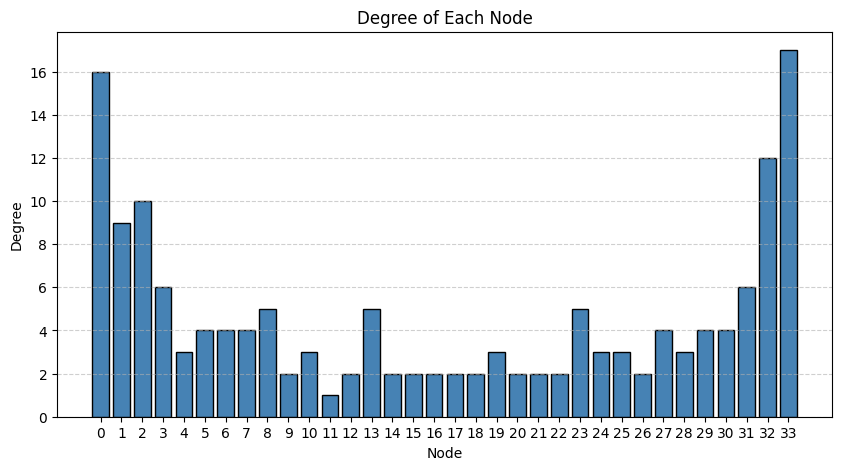

In [28]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.karate_club_graph()

# 1 Number of nodes
print("Number of nodes:", G.number_of_nodes())

# 2 Number of edges
print("Number of edges:", G.number_of_edges())

# 3 Plot
pos = nx.spring_layout(G, seed=42)

degrees = dict(G.degree())
node_sizes = [200 + 40 * degrees[node] for node in G.nodes()]

plt.figure(figsize=(10, 8))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    node_color="lightblue",
    edge_color="gray",
    edgecolors="black",
    width=1.5,
    font_size=9,
    font_weight="bold"
)

plt.title("Karate Club Network")
plt.axis("off")

nodes = list(degrees.keys())
degree_values = list(degrees.values())

plt.figure(figsize=(10,5))

plt.bar(nodes, degree_values, color="steelblue", edgecolor="black")

plt.title("Degree of Each Node")
plt.xlabel("Node")
plt.ylabel("Degree")
plt.xticks(nodes)
plt.grid(axis="y", linestyle="--", alpha=0.6)

# 6
print("Degree of node 0:", degrees[0])
print("Degree of node 33:", degrees[33])